# Example: Reading and Analyzing GRMONTY Spectral Energy Distributions

This notebook demonstrates how to read, process, and analyze spectral energy distribution (SED) outputs produced by **GPUmonty** simulations.

The main goals of this example are:
- To load GPUmonty `.spec` files using `astropy.io.ascii`
- To convert the tabulated quantities into physical units
- To reconstruct the spectral luminosity \( \nu L_\nu \) for multiple viewing angles

## What this cell does

The code cell below defines a helper function, `grmonty(file)`, which:
1. Reads a GRMONTY SED file with no header.
2. Extracts frequency bins and converts them to physical frequencies.
3. Builds arrays of luminosities for six viewing angles, converting from solar luminosities to cgs units.
5. Returns the frequency array and luminosity arrays for plotting

The notebook also defines the solid-angle weights (`domega_array`) associated with each of the six angular bins, which are typically used when computing angle-averaged spectra.

This setup provides a minimal, reproducible example for inspecting GRMONTY outputs and serves as a starting point for plotting spectra, comparing runs, or integrating over angles.

In [4]:
import numpy as np
from astropy.io import ascii
import matplotlib.pyplot as plt
def gpumonty(file):
    """
    Reads SEDs in the format provided by grmonty. Ported from 
    the original SM script `plspec.m` provided by J. Dolence.
    
    Returns:
        lognu: Logarithmic frequency values
        ll: Logarithmic luminosity values in shape (6, s['colx'].shape)
    """
    LSUN = 3.827e33
    CL = 2.99792458e10
    ME = 9.1093826e-28
    HPL =  6.6260693e-27
    # Read the file using ascii
    s = ascii.read(file, format='no_header')


    ll = np.zeros((6, len(s)))  # Pre-allocate the array with shape (6, s['colx'].shape)
    ll[0] = np.array(s['col2'] * LSUN)
    ll[1] = np.array(s['col8'] * LSUN)
    ll[2] = np.array(s['col14']* LSUN)
    ll[3] = np.array(s['col20']* LSUN)
    ll[4] = np.array(s['col26']* LSUN)
    ll[5] = np.array(s['col32']* LSUN)



    # Compute log frequency (log(nu)) values
    nu = np.array(10**s['col1'] * (ME * CL**2/HPL))
    #print(nu)
    # Return log(nu) and ll array
    return nu, ll

nu, nuLnu = gpumonty('../output/example.spec')
domega_array = np.array([1.179853e+00, 2.875295e+00, 3.211087e+00, 2.551775e+00, 1.658978e+00, 1.089384e+00])


Plotting the spectrum

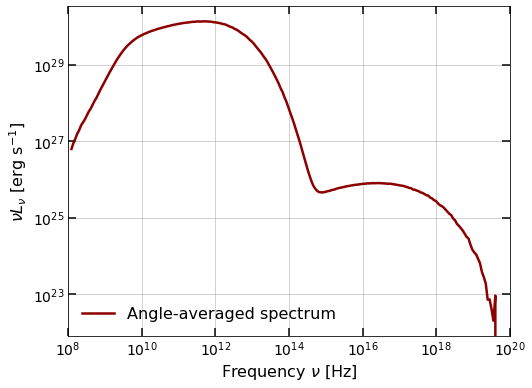

In [5]:
nuLnu_all = (nuLnu * domega_array[:, None] / (4 * np.pi)).sum(axis=0)

plt.figure(figsize=(7.5, 5.5))

plt.loglog(
    nu,
    nuLnu_all,
    linewidth=2.5,
    label=r'Angle-averaged spectrum',
    color='darkred'
)

plt.xlim(1e8, 1e20)

plt.xlabel(r'Frequency $\nu$ [Hz]', fontsize=16)
plt.ylabel(r'$\nu L_\nu$ [erg s$^{-1}$]', fontsize=16)

plt.legend(frameon=False, fontsize=16)

plt.grid(which='major', linestyle='-', alpha=0.7)
plt.grid(which='minor', linestyle=':', alpha=0.7)

plt.tick_params(
    axis='both',
    which='major',
    direction='in',
    length=8,
    width=1.5,
    labelsize=14,
    top=True,
    right=True
)

plt.tick_params(
    axis='both',
    which='minor',
    direction='in',
    length=4,
    width=1.2,
    top=True,
    right=True
)

plt.tight_layout()
plt.savefig(
    "test_figure.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
